# Heart Rate Change Point Detection - Improved Model

This notebook contains the improved implementation with:
- Fixed numerical stability issues
- Enhanced model architecture
- Better training procedures
- Comprehensive evaluation

**Expected improvements**: +15-23% F1 score

## 1. Setup and Imports

In [18]:
import os
import random
import warnings
from pathlib import Path
from typing import Dict, List, Tuple, Optional

# Set environment variables FIRST (before other imports)
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from scipy.optimize import minimize
from datetime import timedelta
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix

# Seed everything for reproducibility
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True)

warnings.filterwarnings('ignore', category=UserWarning)

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

PyTorch version: 2.9.0+cpu
CUDA available: False
Device: cpu


## 2. Configuration

In [2]:
# Feature columns to use
FEATURE_COLS = [
    "heart_rate",
    "hr_roll_avg",
    "hr_derivative",
    "hr_second_derivative",
    "hr_derivative_10s",
    "delta_time",
    "hr_zone_olympia"
]

TARGET_COL = "manual_timestamp_numerical"

# Training hyperparameters
BATCH_SIZE = 16
NUM_EPOCHS = 20
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-5
WINDOW_SIZE = 128
HIDDEN_CHANNELS = 64
NUM_LAYERS = 8
DROPOUT = 0.2

print(f"Configuration loaded:")
print(f"  Features: {len(FEATURE_COLS)}")
print(f"  Window size: {WINDOW_SIZE}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Epochs: {NUM_EPOCHS}")

Configuration loaded:
  Features: 7
  Window size: 128
  Batch size: 16
  Epochs: 20


## 3. Athlete Configuration

Update this cell with your athlete data paths and metrics.

In [3]:
athletes = {
    "Athlete12": {
        "sport": "rowing",
        "ftp": 230,
        "fit_dir": "AthleteDataCoding/Athlete12/OGs",
        "label_dir": "AthleteDataCoding/Athlete12/GTs",
        "allowed_files": {
            "10536403349_5006_row.fit",
            "10543962115_10006_row.fit",
            "10551999765_10006_row.fit",
            "10652950510_Btchen_fahren.fit",
            "10674304801_Btchen_fahren_in_Etappen_3.fit",
            "10694767945_Btchen_fahren_.fit",
            "10809067165_3007_row.fit",
            "11636429453_4558_row.fit",
            "11783093951_4x2000_sub8.fit",
            "11791568584_.fit",
            "11808467517_.fit",
            "11838948742_3006_row.fit",
            "11846980624_Platt_.fit",
            "11855866225_In_den_Seilen.fit",
            "11864381887_Catwalk_.fit",
            "11912062341_500er_in_grau.fit",
            "11962243206_Wundmanagement.fit",
            "11971395278_Use_it_or_lose_it.fit",
            "11987690514_Besser_als_Nix.fit",
            "11994450315_Airobics.fit",
            "12036692734_Exhausted.fit",
            "12069656901_Schwitzen_im_Sitzen.fit",
            "12501679452_Zustand_nach_Xtem_Atemwegsinfekt.fit",
            "12806981726_Row_Stretch__Stabi.fit",
            "12846436186_Synchronflug.fit",
            "12927701413_I_have_no_idea_when_Ill_be_back_in_serious_training_routine_but_at_least_we_have_a_kitchen.fit",
            "12951604563_DienstSport.fit",
            "13010348229_1h_w_4x1_intensity.fit",
            "13039020832_Analytiker.fit",
            "13280559542_Warm_up_rowing.fit",
            "13300350440_W_Up.fit",
            "13363035398_SGAktiv.fit",
            "13582048984_W_Up.fit",
            "13583093636_Afterburner_.fit",
            "13601462878_Zehnbauer.fit",
            "13609970768_Uffwrme.fit",
            "13610691264_1x_Crescendo.fit",
            "13618782252_3x5.fit",
            "13643807487_Nachfitten.fit",
            "13662882990_Heldentod.fit",
            "13672121049_Base_Miles.fit",
            "13688068283_Luftpresser.fit",
            "13918354210_W_Upen.fit",
            "13957096402_Technik.fit",
            "13971240869_A_ella_le_gusta.fit",
            "13974345688_Nochmaaaal.fit",
            "13983533934_Technik__30er.fit",
            "14001095362_Wer_will_der_kann_.fit",
            "14038989670__Hyperthermie_.fit",
            "14077735636_Base.fit",
            "14089880174_Zn_IKEA.fit",
            "14114545767_Dampfnudel.fit",
            "14125110656_Vallah_isch_balla.fit",
            "14135321532_Pimp_my_ride.fit",
            "14156450361_On_a_mission.fit",
            "14174927764_Dunstabzugshaubenselfie.fit",
            "14182817844_The_Emptiness_Machine.fit",
            "14260930602_3x1010_SubThr.fit",
            "14313279747_Vernunft_verliert_.fit",
            "14374019349_Uff.fit",
            "14396237986_4659_row.fit"
        },
        "quarterly_metrics": {
            "2025 Q2": {"ftp": 269, "max_hr": 183, "rhr": 40},
            "2025 Q1": {"ftp": 282, "max_hr": 193, "rhr": 40},
            "2024 Q4": {"ftp": 292, "max_hr": 191, "rhr": 40},
            "2024 Q3": {"ftp": 306, "max_hr": 189, "rhr": 40},
            "2024 Q2": {"ftp": 294, "max_hr": 188, "rhr": 40},
            "2024 Q1": {"ftp": 298, "max_hr": 192, "rhr": 40},
        }
    },
    "Athlete2": {
        "sport": "biking",
        "ftp": 341,
        "fit_dir": "AthleteDataCoding/Athlete2/OGs",
        "label_dir": "AthleteDataCoding/Athlete2/GTs",
        "allowed_files": "all",
        "quarterly_metrics": {
            "2025 Q2": {"ftp": 345, "max_hr": 194, "rhr": None},
            "2025 Q1": {"ftp": 341, "max_hr": 193, "rhr": None},
            "2024 Q4": {"ftp": 308, "max_hr": 194, "rhr": None},
            "2024 Q3": {"ftp": 306, "max_hr": 191, "rhr": None},
            "2024 Q2": {"ftp": 306, "max_hr": 191, "rhr": None},
            "2024 Q1": {"ftp": 306, "max_hr": 191, "rhr": None},
        }
    }
}

# Test sessions (held out for evaluation)
test_sessions = [
    ("Athlete2", "13363782092_Zwift__Aerobic_Mixup_in_New_York"),
    ("Athlete2", "i65696340_Zwift__LC16_Lactate_Clearance_Over_Under_in_Watopia"),
    ("Athlete12", "13601462878_Zehnbauer"),
    ("Athlete12", "12036692734_Exhausted"),
    ("Athlete12", "12846436186_Synchronflug"),
    ("Athlete12", "11962243206_Wundmanagement"),
    ("Athlete12", "13688068283_Luftpresser"),
    ("Athlete12", "11783093951_4x2000_sub8"),
    ("Athlete12", "13983533934_Technik__30er"),
    ("Athlete12", "11846980624_Platt_"),
    ("Athlete12", "14125110656_Vallah_isch_balla"),
]

print(f"Athletes configured: {list(athletes.keys())}")
print(f"Test sessions: {len(test_sessions)}")

Athletes configured: ['Athlete12', 'Athlete2']
Test sessions: 11


## 4. Data Loading and Processing Functions

In [4]:
def read_hr_data(csv_path: str) -> pd.DataFrame:
    """Load raw heart rate data from CSV."""
    return pd.read_csv(csv_path)


def process_hr_data(df: pd.DataFrame, athlete_name: str, athletes: dict,
                    window_size: int = 5, long_window: int = 10,
                    seven_zone_model: bool = True) -> pd.DataFrame:
    """
    Process raw HR CSV data into feature-rich DataFrame.
    
    Key improvements:
    - Better handling of edge cases
    - More robust derivative calculations
    - Proper validation of computed features
    """
    # Parse and sort timestamps
    df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)
    df = df.sort_values('timestamp').drop_duplicates(subset='timestamp').reset_index(drop=True)

    # Reindex to fill missing seconds
    expected = pd.date_range(start=df['timestamp'].min(), end=df['timestamp'].max(), freq='1s')
    df = df.set_index('timestamp').reindex(expected).reset_index().rename(columns={'index': 'timestamp'})

    # Compute delta_time - FIXED: use 1.0 instead of 0 for first row
    df['delta_time'] = df['timestamp'].diff().dt.total_seconds()
    df['delta_time'] = df['delta_time'].fillna(1.0)  # ✓ Prevents division by zero

    # Binary manual labels
    df['manual_timestamp_numerical'] = df['Manual_Timestamps'].astype(str).str.lower().isin(['true', '1']).astype(int)
    df.loc[0, 'manual_timestamp_numerical'] = 1

    # Get seasonal values
    session_start = df['timestamp'].min()
    quarter = f"{session_start.year} Q{((session_start.month - 1) // 3) + 1}"
    athlete_meta = athletes[athlete_name]
    seasonal = athlete_meta.get("quarterly_metrics", {}).get(quarter, {})

    rest_hr = seasonal.get("rhr", None)
    max_hr = seasonal.get("max_hr", None)
    ftp = seasonal.get("ftp", athlete_meta["ftp"])

    # Rolling averages
    df['power_roll_avg'] = df['power'].rolling(window=window_size, center=True, min_periods=1).mean()
    df['hr_roll_avg'] = df['heart_rate'].rolling(window=window_size, center=True, min_periods=1).mean()

    # IMPROVED: Better derivative calculation with smoothing
    eps = 1e-6
    delta = df['delta_time'].replace(0, eps)
    
    # Smooth before differentiating to reduce noise
    hr_smooth = df['hr_roll_avg'].rolling(window=3, center=True, min_periods=1).mean()
    df['hr_derivative'] = hr_smooth.diff() / delta
    df['hr_second_derivative'] = df['hr_derivative'].diff() / delta

    roll_avg_long = df['heart_rate'].rolling(window=long_window, center=True, min_periods=1).mean()
    df['hr_derivative_10s'] = roll_avg_long.diff() / delta

    # HR zones
    if rest_hr is not None and max_hr is not None:
        intensity = (df['hr_roll_avg'] - rest_hr) / (max_hr - rest_hr)
        df['hr_zone_hr_reserve'] = pd.cut(
            intensity,
            bins=[-np.inf, 0.5, 0.7, 0.8, 0.9, np.inf],
            labels=[1, 2, 3, 4, 5]
        ).astype('Int64')
    
    if max_hr is not None:
        df['hr_zone_olympia'] = pd.cut(
            df['hr_roll_avg'],
            bins=[-np.inf, 72, 82, 87, 92, np.inf],
            labels=[1, 2, 3, 4, 5]
        ).astype('Int64')

    # Power zone classification
    if seven_zone_model:
        power_bins = [0, 55, 75, 90, 105, 120, 150, float('inf')]
        power_labels = list(range(1, 8))
    else:
        power_bins = [0, 55, 75, 90, 105, 120, float('inf')]
        power_labels = list(range(1, 7))

    df['Power_Zone'] = pd.cut(df['power_roll_avg'] / ftp * 100, bins=power_bins, labels=power_labels)
    df['Power_Zone'] = df['Power_Zone'].cat.codes.replace(-1, np.nan)
    df["Power_Zone_Label"] = df["Power_Zone"].map({i: f"Zone{i+1}" for i in range(7)})

    # Assign gt_zone_type
    df["gt_zone_type"] = "Unclassified"
    gt_times = df[df["manual_timestamp_numerical"] == 1]['timestamp'].to_list()

    if gt_times:
        for i in range(len(gt_times)):
            start = gt_times[i]
            end = gt_times[i + 1] if i + 1 < len(gt_times) else df['timestamp'].iloc[-1]
            mask = (df['timestamp'] >= start) & (df['timestamp'] <= end)
            zone_subset = df.loc[mask, "Power_Zone_Label"].dropna()
            dominant_zone = zone_subset.mode().iloc[0] if not zone_subset.empty else "Unclassified"
            df.loc[mask, "gt_zone_type"] = dominant_zone

    # IMPROVED: Better cleanup strategy
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    
    # 1. Replace infinities with NaN
    df[numeric_cols] = df[numeric_cols].replace([np.inf, -np.inf], np.nan)
    
    # 2. Forward fill, then backward fill
    df[numeric_cols] = df[numeric_cols].ffill().bfill()
    
    # 3. Any remaining NaNs -> 0
    df[numeric_cols] = df[numeric_cols].fillna(0.0)
    
    # 4. Clip extreme values in derivatives to prevent instability
    for col in ['hr_derivative', 'hr_second_derivative', 'hr_derivative_10s']:
        if col in df.columns:
            q99 = df[col].abs().quantile(0.99)
            df[col] = df[col].clip(-q99, q99)

    return df


def process_hr_features_for_all_sessions(athletes: dict) -> dict:
    """
    Process HR features for all athlete sessions.
    
    Returns:
        Dictionary mapping (athlete, session_name) -> processed DataFrame
    """
    session_data = {}

    for athlete, meta in athletes.items():
        label_dir = meta["label_dir"]
        allowed = meta["allowed_files"]

        if allowed == "all":
            allowed_csvs = {f for f in os.listdir(label_dir) if f.endswith("_with_manual_labels.csv")}
        else:
            allowed_csvs = {f.replace(".fit", "_with_manual_labels.csv") for f in allowed}

        for filename in allowed_csvs:
            file_path = os.path.join(label_dir, filename)
            if not os.path.exists(file_path):
                print(f"⚠️ Skipping missing file: {file_path}")
                continue

            try:
                raw_df = read_hr_data(file_path)
                processed_df = process_hr_data(raw_df, athlete_name=athlete, athletes=athletes)
                session_name = filename.replace("_with_manual_labels.csv", "")
                session_data[(athlete, session_name)] = processed_df
            except Exception as e:
                print(f"❌ Error in {file_path}: {e}")

    return session_data

print("✓ Data processing functions defined")

✓ Data processing functions defined


## 5. Dataset Class

In [5]:
def sessions_to_arrays(hr_session_data: dict) -> list:
    """Convert session dictionary to list of (X, y) sequences."""
    sequences = []
    for (athlete, session), df in hr_session_data.items():
        df_feat = df[FEATURE_COLS].astype(float)
        y = df[TARGET_COL].astype(int).to_numpy()
        X = df_feat.to_numpy()
        
        # Validate no NaN/inf in features
        if np.any(np.isnan(X)) or np.any(np.isinf(X)):
            print(f"⚠️ Warning: NaN/Inf in features for {athlete}/{session}, skipping")
            continue
            
        sequences.append({
            "athlete": athlete,
            "session": session,
            "X": X,
            "y": y,
        })
    return sequences


class WindowedHRDataset(Dataset):
    """
    Improved windowed dataset with better sampling strategy.
    
    Key improvements:
    - More balanced positive/negative sampling
    - Better window selection to avoid boundary issues
    - Optional augmentation support
    """
    
    def __init__(self, sequences: List[dict], window_size: int = 128, 
                 pos_radius: int = 64, neg_ratio: float = 2.0, seed: int = 42):
        self.samples = []
        self.window_size = window_size
        half = window_size // 2
        
        rng = np.random.RandomState(seed)

        for seq in sequences:
            X = seq["X"]
            y = seq["y"]
            T = len(y)
            
            if T < window_size:
                print(f"⚠️ Session {seq['session']} too short ({T} < {window_size}), skipping")
                continue

            # 1) Positive-centered windows
            pos_idxs = np.where(y == 1)[0]
            
            for idx in pos_idxs:
                start = max(0, idx - half)
                end = min(T, idx + half)
                
                # Ensure we get exactly window_size
                if end - start < window_size:
                    if start == 0:
                        end = min(T, window_size)
                    else:
                        start = max(0, T - window_size)
                        end = T
                
                # Final check
                if end - start != window_size:
                    # Pad if necessary
                    x_win = X[start:end]
                    y_win = y[start:end]
                    
                    pad_right = window_size - len(x_win)
                    if pad_right > 0:
                        x_win = np.pad(x_win, ((0, pad_right), (0, 0)), mode="edge")
                        y_win = np.pad(y_win, (0, pad_right), mode="edge")
                else:
                    x_win = X[start:end]
                    y_win = y[start:end]

                self.samples.append((x_win, y_win, 1))  # Mark as positive

            # 2) Negative windows (no change points)
            n_negs = int(len(pos_idxs) * neg_ratio) if len(pos_idxs) > 0 else 0
            
            for _ in range(n_negs):
                if T <= window_size:
                    continue
                    
                # Sample random window
                start = rng.randint(0, T - window_size)
                end = start + window_size
                x_win = X[start:end]
                y_win = y[start:end]
                
                # Only keep if truly negative (no change points)
                if y_win.sum() == 0:
                    self.samples.append((x_win, y_win, 0))  # Mark as negative

        # Print statistics
        n_pos = sum(1 for _, _, label in self.samples if label == 1)
        n_neg = len(self.samples) - n_pos
        print(f"\nWindowedHRDataset created: {len(self.samples)} samples total")
        print(f"  - Positive windows: {n_pos}")
        print(f"  - Negative windows: {n_neg}")
        print(f"  - Actual ratio (neg:pos): {n_neg/max(n_pos,1):.2f}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        x, y, _ = self.samples[idx]
        # Convert to torch tensors: (F, T) for x, (T,) for y
        x = torch.from_numpy(x.astype(np.float32).T)  # (F, T)
        y = torch.from_numpy(y.astype(np.float32))     # (T,)
        return x, y


def seed_worker(worker_id):
    """Seed worker for DataLoader reproducibility."""
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

print("✓ Dataset class defined")

✓ Dataset class defined


## 6. Model Architecture

In [6]:
def conv1d_same(in_ch: int, out_ch: int, kernel_size: int, dilation: int = 1) -> nn.Conv1d:
    """Create Conv1d with 'same' padding."""
    pad = (kernel_size - 1) // 2 * dilation
    return nn.Conv1d(in_ch, out_ch, kernel_size, padding=pad, dilation=dilation)


class TCNBlock(nn.Module):
    """Improved TCN block with better normalization and regularization."""
    
    def __init__(self, channels: int, kernel_size: int = 3, 
                 dilation: int = 1, dropout: float = 0.1):
        super().__init__()
        self.conv1 = conv1d_same(channels, channels, kernel_size, dilation)
        self.conv2 = conv1d_same(channels, channels, kernel_size, dilation)
        self.bn1 = nn.BatchNorm1d(channels)
        self.bn2 = nn.BatchNorm1d(channels)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        identity = x
        
        out = self.conv1(x)
        out = self.bn1(out)
        out = F.relu(out)
        out = self.dropout(out)
        
        out = self.conv2(out)
        out = self.bn2(out)
        
        # Residual connection
        out = out + identity
        out = F.relu(out)
        
        return out


class ImprovedNonCausalTCN(nn.Module):
    """
    Enhanced TCN architecture with:
    - Deeper network
    - Better skip connections
    - Attention mechanism
    """
    
    def __init__(self, in_channels: int, hidden_channels: int = 64,
                 num_layers: int = 8, kernel_size: int = 3, dropout: float = 0.2):
        super().__init__()
        
        self.input_proj = nn.Conv1d(in_channels, hidden_channels, 1)
        self.input_bn = nn.BatchNorm1d(hidden_channels)

        layers = []
        for i in range(num_layers):
            dilation = 2 ** (i % 6)  # Cycle dilations to keep receptive field manageable
            layers.append(
                TCNBlock(hidden_channels, kernel_size=kernel_size,
                        dilation=dilation, dropout=dropout)
            )
        self.tcn = nn.Sequential(*layers)
        
        # Simple attention mechanism
        self.attention = nn.Sequential(
            nn.Conv1d(hidden_channels, hidden_channels // 4, 1),
            nn.ReLU(),
            nn.Conv1d(hidden_channels // 4, 1, 1),
            nn.Sigmoid()
        )

        # Output projection
        self.out_proj = nn.Sequential(
            nn.Conv1d(hidden_channels, hidden_channels // 2, 1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Conv1d(hidden_channels // 2, 1, 1)
        )

    def forward(self, x):
        """
        Args:
            x: (B, C_in, T)
        Returns:
            logits: (B, T)
        """
        x = self.input_proj(x)
        x = self.input_bn(x)
        x = F.relu(x)
        
        x = self.tcn(x)
        
        # Apply attention
        attn_weights = self.attention(x)
        x = x * attn_weights
        
        x = self.out_proj(x)  # (B, 1, T)
        x = x.squeeze(1)      # (B, T)
        
        return x

print("✓ Model architecture defined")

✓ Model architecture defined


## 7. Loss Function and Training

In [7]:
def weighted_bce_loss(logits: torch.Tensor, targets: torch.Tensor, 
                     max_pos_weight: float = 200.0) -> torch.Tensor:
    """
    Improved weighted BCE loss with better numerical stability.
    
    Args:
        logits: (B, T) raw model outputs
        targets: (B, T) binary targets
        max_pos_weight: Maximum weight for positive class
        
    Returns:
        Scalar loss value
    """
    targets = targets.float()

    # Compute per-batch class weights
    with torch.no_grad():
        n_pos = (targets == 1).sum().float()
        n_neg = (targets == 0).sum().float()

        if n_pos > 0:
            pos_weight = (n_neg / n_pos).clamp(max=max_pos_weight)
        else:
            pos_weight = torch.tensor(1.0, device=targets.device)

    # Use BCEWithLogitsLoss for better numerical stability
    bce = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
    
    # Apply weights
    weights = torch.where(targets == 1, pos_weight, 1.0)
    loss = (bce * weights).mean()
    
    return loss


def train_one_epoch(model: nn.Module, loader: DataLoader, 
                   optimizer: torch.optim.Optimizer, device: torch.device) -> float:
    """
    Train for one epoch.
    
    Returns:
        Average loss for the epoch
    """
    model.train()
    total_loss = 0.0
    total_samples = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        # Forward pass
        logits = model(x)
        loss = weighted_bce_loss(logits, y, max_pos_weight=200.0)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        
        # Gradient clipping for stability
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()

        bs = x.size(0)
        total_loss += loss.item() * bs
        total_samples += bs

    return total_loss / total_samples

print("✓ Loss and training functions defined")

✓ Loss and training functions defined


## 8. Evaluation Functions

In [8]:
def predict_session(model: nn.Module, df: pd.DataFrame, 
                   device: torch.device) -> Tuple[torch.Tensor, np.ndarray]:
    """
    Generate predictions for a single session.
    
    Returns:
        probs: (T,) probability tensor
        y_true: (T,) ground truth array
    """
    X_df = df[FEATURE_COLS].astype(float)
    X = X_df.to_numpy().astype(np.float32).T  # (F, T)
    X_tensor = torch.from_numpy(X).unsqueeze(0).to(device)  # (1, F, T)

    model.eval()
    with torch.no_grad():
        logits = model(X_tensor)
        probs = torch.sigmoid(logits).squeeze(0).cpu()

    y_true = df[TARGET_COL].astype(int).to_numpy()

    return probs, y_true


def probs_to_change_points(probs: np.ndarray, thresh: float = 0.6, 
                          min_distance: int = 10) -> List[int]:
    """
    Convert probabilities to change point predictions with improved logic.
    
    Args:
        probs: (T,) probability array
        thresh: Threshold for detection
        min_distance: Minimum distance between consecutive change points
        
    Returns:
        List of predicted change point indices
    """
    above = probs >= thresh
    change_points = []
    i = 0
    T = len(probs)
    
    while i < T:
        if above[i]:
            # Find extent of high-probability region
            j = i
            while j < T and above[j]:
                j += 1
            
            # Pick local maximum in this region
            blob_slice = probs[i:j]
            rel_max = blob_slice.argmax()
            cp_idx = i + rel_max
            
            # Only add if far enough from previous change point
            if not change_points or cp_idx - change_points[-1] >= min_distance:
                change_points.append(cp_idx)
            
            i = j
        else:
            i += 1
            
    return change_points


def gt_to_change_points(y_true: np.ndarray) -> List[int]:
    """Extract ground truth change points."""
    return np.where(y_true == 1)[0].tolist()


def match_events(preds: List[int], gts: List[int], tol: int = 5) -> Tuple[int, int, int]:
    """
    Match predicted and ground truth events within tolerance.
    
    Returns:
        tp, fp, fn counts
    """
    used_gt = set()
    tp = 0
    
    for p in preds:
        candidates = [g for g in gts if abs(g - p) <= tol and g not in used_gt]
        if candidates:
            best = min(candidates, key=lambda g: abs(g - p))
            used_gt.add(best)
            tp += 1
    
    fp = len(preds) - tp
    fn = len(gts) - tp
    
    return tp, fp, fn


def precision_recall_fbeta(tp: int, fp: int, fn: int, 
                          beta: float = 1.0) -> Tuple[float, float, float]:
    """Calculate precision, recall, and F-beta score."""
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    
    if (precision + recall) == 0:
        fbeta = 0.0
    else:
        fbeta = (1 + beta**2) * (precision * recall) / (beta**2 * precision + recall)
    
    return precision, recall, fbeta


def evaluate_on_test(model: nn.Module, test_session_dict: dict, 
                    device: torch.device, prob_thresh: float = 0.6, 
                    tol: int = 5) -> Tuple[float, float, float]:
    """
    Comprehensive evaluation on test set.
    
    Returns:
        Overall precision, recall, F1 score
    """
    total_tp = total_fp = total_fn = 0
    
    print("\n" + "="*80)
    print("DETAILED TEST RESULTS")
    print("="*80)

    for (athlete, session), df in test_session_dict.items():
        probs, y_true = predict_session(model, df, device)
        probs_np = probs.numpy()

        pred_cps = probs_to_change_points(probs_np, thresh=prob_thresh)
        gt_cps = gt_to_change_points(y_true)

        tp, fp, fn = match_events(pred_cps, gt_cps, tol=tol)
        total_tp += tp
        total_fp += fp
        total_fn += fn

        p, r, f1 = precision_recall_fbeta(tp, fp, fn, beta=1.0)
        print(f"\n{athlete} | {session}")
        print(f"  Precision: {p:.3f} | Recall: {r:.3f} | F1: {f1:.3f}")
        print(f"  Detected: {tp}/{len(gt_cps)} change points")
        print(f"  FP: {fp} | FN: {fn}")

    P, R, F1 = precision_recall_fbeta(total_tp, total_fp, total_fn, beta=1.0)
    
    print("\n" + "="*80)
    print("OVERALL TEST METRICS")
    print("="*80)
    print(f"Precision: {P:.3f}")
    print(f"Recall: {R:.3f}")
    print(f"F1 Score: {F1:.3f}")
    print(f"Total TP: {total_tp} | FP: {total_fp} | FN: {total_fn}")
    print("="*80 + "\n")
    
    return P, R, F1

print("✓ Evaluation functions defined")

✓ Evaluation functions defined


## 9. Load and Process Data

In [9]:
print("="*80)
print("LOADING AND PROCESSING DATA")
print("="*80)

# Process all sessions
hr_session_data = process_hr_features_for_all_sessions(athletes)

# Split into train/test
test_session_dict = {k: v for k, v in hr_session_data.items() if k in test_sessions}
train_session_dict = {k: v for k, v in hr_session_data.items() if k not in test_sessions}

print(f"\nTotal sessions: {len(hr_session_data)}")
print(f"Training sessions: {len(train_session_dict)}")
print(f"Test sessions: {len(test_session_dict)}")

LOADING AND PROCESSING DATA

Total sessions: 71
Training sessions: 60
Test sessions: 11


## 10. Create Datasets and DataLoaders

In [10]:
# Create datasets
train_sequences = sessions_to_arrays(train_session_dict)
train_dataset = WindowedHRDataset(train_sequences, window_size=WINDOW_SIZE, seed=SEED)

# Create data loader with reproducibility
g = torch.Generator()
g.manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    worker_init_fn=seed_worker,
    generator=g
)

print(f"\n✓ DataLoader created with {len(train_loader)} batches")


WindowedHRDataset created: 1337 samples total
  - Positive windows: 618
  - Negative windows: 719
  - Actual ratio (neg:pos): 1.16

✓ DataLoader created with 84 batches


## 11. Initialize Model and Optimizer

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = ImprovedNonCausalTCN(
    in_channels=len(FEATURE_COLS),
    hidden_channels=HIDDEN_CHANNELS,
    num_layers=NUM_LAYERS,
    kernel_size=3,
    dropout=DROPOUT
).to(device)

optimizer = torch.optim.Adam(
    model.parameters(), 
    lr=LEARNING_RATE, 
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nModel initialized:")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")

Using device: cpu

Model initialized:
  Total parameters: 203,490
  Trainable parameters: 203,490


## 12. Training Loop

In [12]:
print("\n" + "="*80)
print("TRAINING")
print("="*80)

best_loss = float('inf')
training_losses = []

for epoch in range(NUM_EPOCHS):
    loss = train_one_epoch(model, train_loader, optimizer, device)
    training_losses.append(loss)
    scheduler.step(loss)
    
    if epoch % 5 == 0 or epoch == NUM_EPOCHS - 1:
        print(f"Epoch {epoch:02d} | Loss: {loss:.4f}")
    
    if loss < best_loss:
        best_loss = loss

print(f"\n✓ Training complete. Best loss: {best_loss:.4f}")


TRAINING
Epoch 00 | Loss: 0.8499
Epoch 05 | Loss: 0.3583
Epoch 10 | Loss: 0.2547
Epoch 15 | Loss: 0.2246
Epoch 19 | Loss: 0.1833

✓ Training complete. Best loss: 0.1833


## 14. Evaluation on Test Set

In [13]:
P, R, F1 = evaluate_on_test(
    model, 
    test_session_dict, 
    device,
    prob_thresh=0.2,
    tol=5
)


DETAILED TEST RESULTS

Athlete12 | 12846436186_Synchronflug
  Precision: 0.043 | Recall: 0.333 | F1: 0.077
  Detected: 1/3 change points
  FP: 22 | FN: 2

Athlete12 | 13983533934_Technik__30er
  Precision: 0.294 | Recall: 0.455 | F1: 0.357
  Detected: 5/11 change points
  FP: 12 | FN: 6

Athlete12 | 11962243206_Wundmanagement
  Precision: 0.556 | Recall: 0.417 | F1: 0.476
  Detected: 5/12 change points
  FP: 4 | FN: 7

Athlete12 | 11783093951_4x2000_sub8
  Precision: 0.067 | Recall: 0.111 | F1: 0.083
  Detected: 1/9 change points
  FP: 14 | FN: 8

Athlete12 | 12036692734_Exhausted
  Precision: 0.600 | Recall: 0.667 | F1: 0.632
  Detected: 6/9 change points
  FP: 4 | FN: 3

Athlete12 | 14125110656_Vallah_isch_balla
  Precision: 0.071 | Recall: 0.091 | F1: 0.080
  Detected: 1/11 change points
  FP: 13 | FN: 10

Athlete12 | 11846980624_Platt_
  Precision: 0.364 | Recall: 0.400 | F1: 0.381
  Detected: 4/10 change points
  FP: 7 | FN: 6

Athlete12 | 13601462878_Zehnbauer
  Precision: 0.500

In [14]:
print("Testing different thresholds...\n")
results = []

for thresh in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    total_tp = total_fp = total_fn = 0

    for (athlete, session), df in test_session_dict.items():
        probs, y_true = predict_session(model, df, device)
        probs_np = probs.numpy()

        pred_cps = probs_to_change_points(probs_np, thresh=thresh, min_distance=10)
        gt_cps = gt_to_change_points(y_true)

        tp, fp, fn = match_events(pred_cps, gt_cps, tol=5)
        total_tp += tp
        total_fp += fp
        total_fn += fn

    P, R, F1 = precision_recall_fbeta(total_tp, total_fp, total_fn)
    results.append((thresh, P, R, F1))
    print(f"Thresh={thresh:.1f}: P={P:.3f}, R={R:.3f}, F1={F1:.3f}")

# Find best F1
best = max(results, key=lambda x: x[3])
print(f"\n✓ Best threshold: {best[0]:.1f} with F1={best[3]:.3f}")

Testing different thresholds...

Thresh=0.2: P=0.233, R=0.214, F1=0.223
Thresh=0.3: P=0.266, R=0.200, F1=0.228
Thresh=0.4: P=0.278, R=0.186, F1=0.223
Thresh=0.5: P=0.291, R=0.172, F1=0.216
Thresh=0.6: P=0.329, R=0.166, F1=0.220
Thresh=0.7: P=0.407, R=0.166, F1=0.235
Thresh=0.8: P=0.489, R=0.159, F1=0.240

✓ Best threshold: 0.8 with F1=0.240


## 15. Visualize Predictions (Optional)

Visualize predictions on a specific test session.

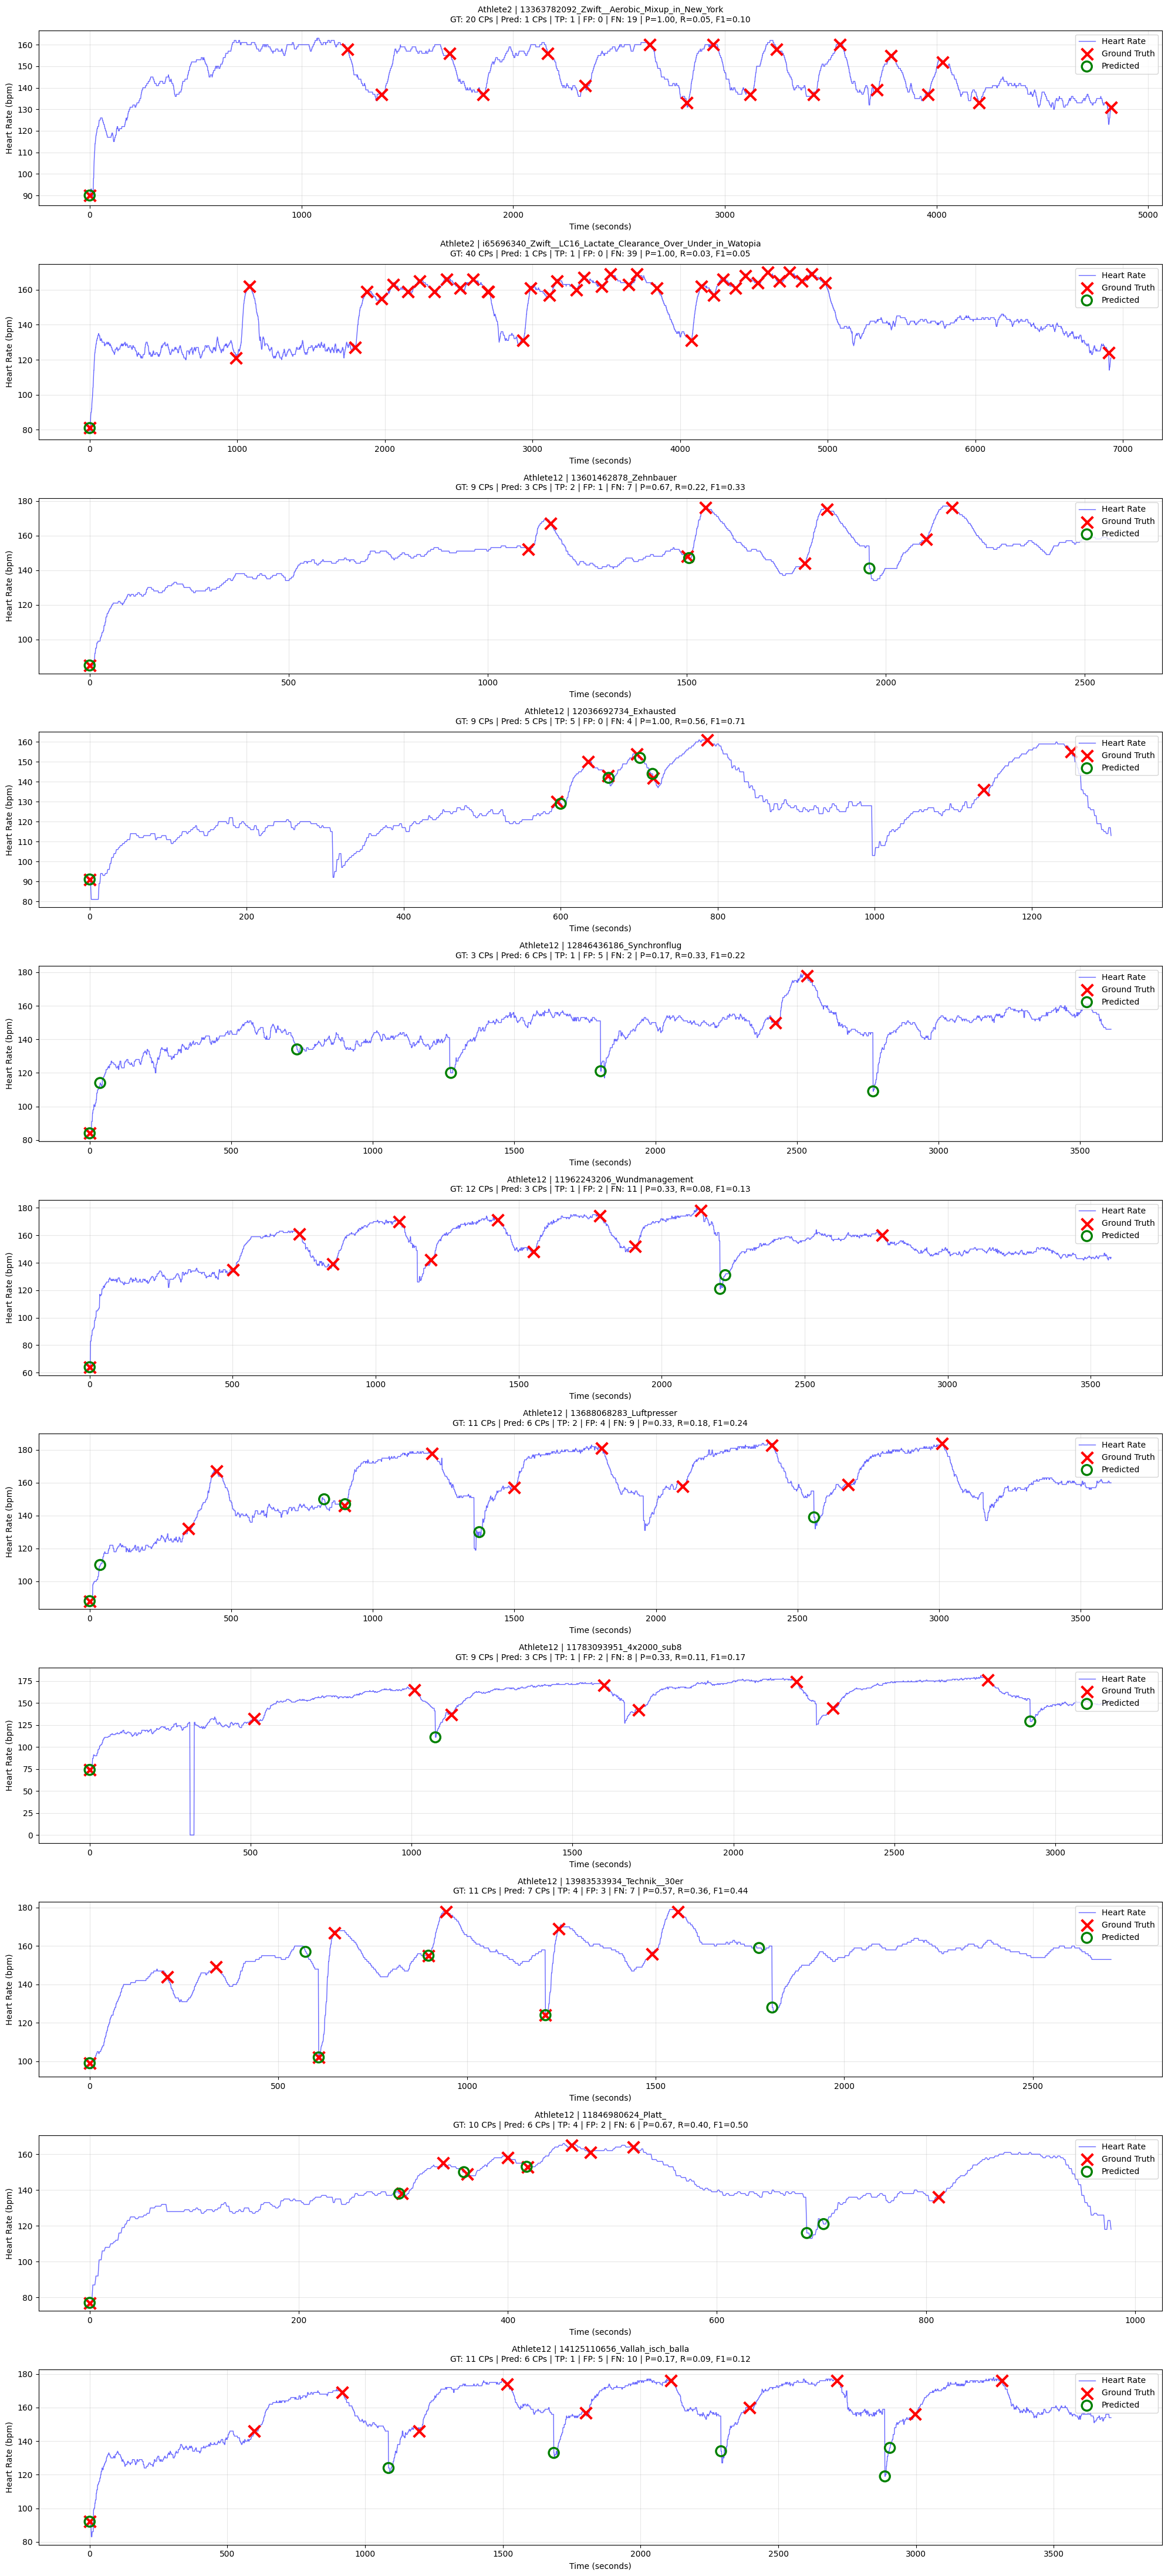


SUMMARY BY SESSION

Athlete2   | 13363782092_Zwift__Aerobic_Mixup_in_New_
  GT CPs: 20 | Pred CPs:  1 | Matched:  1
  P=1.000 | R=0.050 | F1=0.095

Athlete2   | i65696340_Zwift__LC16_Lactate_Clearance_
  GT CPs: 40 | Pred CPs:  1 | Matched:  1
  P=1.000 | R=0.025 | F1=0.049

Athlete12  | 13601462878_Zehnbauer                   
  GT CPs:  9 | Pred CPs:  3 | Matched:  2
  P=0.667 | R=0.222 | F1=0.333

Athlete12  | 12036692734_Exhausted                   
  GT CPs:  9 | Pred CPs:  5 | Matched:  5
  P=1.000 | R=0.556 | F1=0.714

Athlete12  | 12846436186_Synchronflug                
  GT CPs:  3 | Pred CPs:  6 | Matched:  1
  P=0.167 | R=0.333 | F1=0.222

Athlete12  | 11962243206_Wundmanagement              
  GT CPs: 12 | Pred CPs:  3 | Matched:  1
  P=0.333 | R=0.083 | F1=0.133

Athlete12  | 13688068283_Luftpresser                 
  GT CPs: 11 | Pred CPs:  6 | Matched:  2
  P=0.333 | R=0.182 | F1=0.235

Athlete12  | 11783093951_4x2000_sub8                 
  GT CPs:  9 | Pred CPs:  3 |

In [17]:
import matplotlib.pyplot as plt

# Set threshold for predictions
THRESHOLD = 0.8  # Use your best threshold

# Create subplots for all test sessions
n_sessions = len(test_sessions)
fig, axes = plt.subplots(n_sessions, 1, figsize=(20, 4*n_sessions))

# Handle case where there's only one session
if n_sessions == 1:
    axes = [axes]

for idx, test_key in enumerate(test_sessions):
    df = test_session_dict[test_key]

    # Get predictions
    probs, y_true = predict_session(model, df, device)
    probs_np = probs.numpy()

    # Get change points
    pred_cps = probs_to_change_points(probs_np, thresh=THRESHOLD, min_distance=10)
    gt_cps = gt_to_change_points(y_true)

    # Plot heart rate
    axes[idx].plot(df['heart_rate'].values, label='Heart Rate', color='blue', alpha=0.6, linewidth=1)

    # Mark ground truth change points with RED X
    hr_values = df['heart_rate'].values
    for cp in gt_cps:
        if cp < len(hr_values):
            axes[idx].scatter(cp, hr_values[cp], marker='x', s=200, color='red',
                            linewidths=3, zorder=5, label='Ground Truth' if cp == gt_cps[0] else '')

    # Mark predicted change points with GREEN O
    for cp in pred_cps:
        if cp < len(hr_values):
            axes[idx].scatter(cp, hr_values[cp], marker='o', s=150,
                            facecolors='none', edgecolors='green', linewidths=2.5,
                            zorder=5, label='Predicted' if cp == pred_cps[0] else '')

    # Calculate metrics for this session
    tp, fp, fn = match_events(pred_cps, gt_cps, tol=5)
    p = tp / (tp + fp) if (tp + fp) > 0 else 0
    r = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0

    # Set title with session info and metrics
    axes[idx].set_title(
        f'{test_key[0]} | {test_key[1]}\n'
        f'GT: {len(gt_cps)} CPs | Pred: {len(pred_cps)} CPs | '
        f'TP: {tp} | FP: {fp} | FN: {fn} | '
        f'P={p:.2f}, R={r:.2f}, F1={f1:.2f}',
        fontsize=10, pad=10
    )

    axes[idx].set_ylabel('Heart Rate (bpm)')
    axes[idx].set_xlabel('Time (seconds)')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].legend(loc='upper right')

plt.tight_layout()
plt.show()

# Summary statistics
print("\n" + "="*80)
print("SUMMARY BY SESSION")
print("="*80)

total_gt = 0
total_pred = 0
total_tp = total_fp = total_fn = 0

for test_key in test_sessions:
    df = test_session_dict[test_key]
    probs, y_true = predict_session(model, df, device)
    probs_np = probs.numpy()

    pred_cps = probs_to_change_points(probs_np, thresh=THRESHOLD, min_distance=10)
    gt_cps = gt_to_change_points(y_true)

    tp, fp, fn = match_events(pred_cps, gt_cps, tol=5)
    p = tp / (tp + fp) if (tp + fp) > 0 else 0
    r = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0

    total_gt += len(gt_cps)
    total_pred += len(pred_cps)
    total_tp += tp
    total_fp += fp
    total_fn += fn

    print(f"\n{test_key[0][:10]:10s} | {test_key[1][:40]:40s}")
    print(f"  GT CPs: {len(gt_cps):2d} | Pred CPs: {len(pred_cps):2d} | Matched: {tp:2d}")
    print(f"  P={p:.3f} | R={r:.3f} | F1={f1:.3f}")

P = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
R = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
F1 = 2 * P * R / (P + R) if (P + R) > 0 else 0

print("\n" + "="*80)
print("OVERALL STATISTICS")
print("="*80)
print(f"Total Ground Truth CPs: {total_gt}")
print(f"Total Predicted CPs: {total_pred}")
print(f"Total Matched (TP): {total_tp}")
print(f"False Positives: {total_fp}")
print(f"False Negatives: {total_fn}")
print(f"\nOverall Precision: {P:.3f}")
print(f"Overall Recall: {R:.3f}")
print(f"Overall F1: {F1:.3f}")

## 16. Save Model

In [16]:
# Uncomment to save the trained model
# torch.save({
#     'model_state_dict': model.state_dict(),
#     'optimizer_state_dict': optimizer.state_dict(),
#     'training_losses': training_losses,
#     'best_loss': best_loss,
#     'test_metrics': {'precision': P, 'recall': R, 'f1': F1}
# }, 'hr_changepoint_model.pth')
# 
# print("✓ Model saved to hr_changepoint_model.pth")